In [6]:
from PIL import Image
from matplotlib import pyplot as plt
import numpy as np
from pathlib import Path

In [10]:


path = "test_image/Lenna_(test_image).png"

img = Image.open(path).convert("RGB")

def image_size(img: Image.Image) -> tuple[int, int]:
    h, w = img.size
    return h, w

def plot_rgb(img: Image.Image, out_dir: str) -> None:
    channel_names = ["Red (R)", "Green (G)", "Blue (B)"]
    channel_colors = ["Reds", "Greens", "Blues"]

    if out_dir:
        Path(out_dir).mkdir(parents=True, exist_ok=True)

    
    for i, channel in enumerate(img.split()):
        plt.figure(figsize=(5, 5))
        plt.imshow(channel, cmap=channel_colors[i])
        plt.title(channel_names[i])
        plt.axis("off")

        plt.tight_layout()
        if out_dir:
            plt.savefig(f"{out_dir}{channel_names[i].split()[0].lower()}.png")
        plt.show()

def plot_ycbcr(img: Image.Image, out_dir: str) -> None:
    ycbcr = np.array(img.convert("YCbCr"))

    y = ycbcr[:, :, 0]
    cb = ycbcr[:, :, 1]
    cr = ycbcr[:, :, 2]

    neutral = np.full_like(y, 128)

    visualizations = {
        "y": np.stack([y, neutral, neutral], axis=2),
        "cb": np.stack([neutral, cb, neutral], axis=2),
        "cr": np.stack([neutral, neutral, cr], axis=2),
    }

    titles = {
        "y": "Luminance (Y)",
        "cb": "Chrominance (Cb)",
        "cr": "Chrominance (Cr)",
    }

    if out_dir:
        Path(out_dir).mkdir(parents=True, exist_ok=True)

    for name, ycbcr_vis in visualizations.items():
        rgb_vis = Image.fromarray(ycbcr_vis.astype(np.uint8), mode="YCbCr").convert("RGB")

        plt.figure(figsize=(5, 5))
        plt.imshow(rgb_vis)
        plt.title(titles[name])
        plt.axis("off")
        plt.tight_layout()

        if out_dir:
            plt.savefig(Path(out_dir) / f"{name}.png", bbox_inches="tight", dpi=300)

        plt.show()
        plt.close()



Height: 512, Width: 512


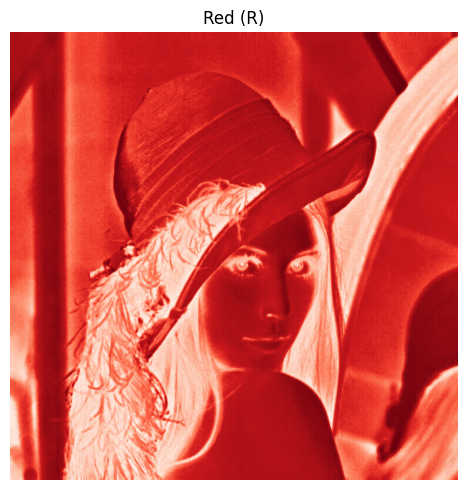

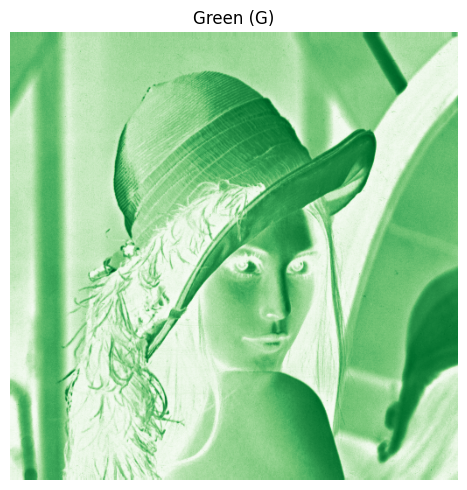

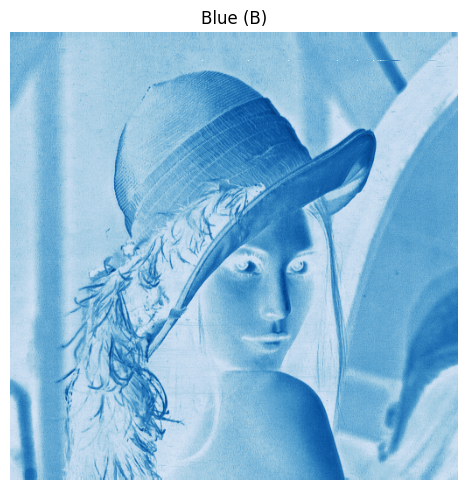

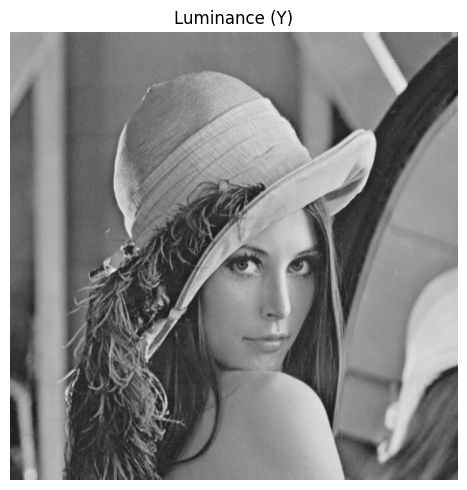

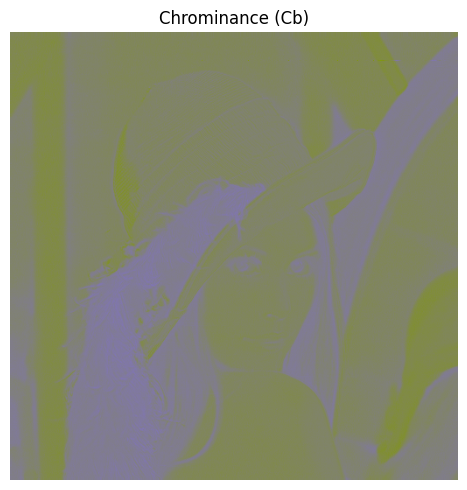

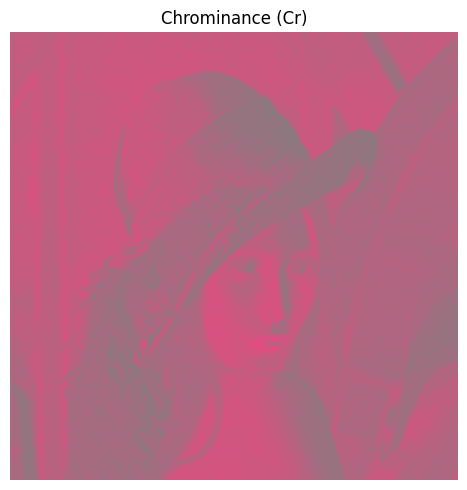

In [11]:
a, b = image_size(img)
print(f"Height: {a}, Width: {b}")

plot_rgb(img, "test_image/")
plot_ycbcr(img, "test_image/")